<a href="https://colab.research.google.com/github/nicolasengland14-gif/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Assignment%203/Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import numpy as np
import pandas as pd

In [23]:
# Data Generating Process
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

In [24]:
n_boot = 10000
n = len(driver_tips)

boot_medians = []

for i in range(n_boot):
    sample_index = np.random.randint(0, n, n)
    sample = driver_tips[sample_index]
    med = np.median(sample)
    boot_medians.append(med)

boot_medians = np.array(boot_medians)

In [25]:
ci_lower = np.percentile(boot_medians, 2.5)
ci_upper = np.percentile(boot_medians, 97.5)

print(ci_lower, ci_upper)

0.2653018357387816 1.3635639228066991


compared to a standard parametic output, this interval is asymmetric due to the long right tail

In [26]:
control = np.random.normal(loc=35, scale=5, size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)
observed_simple_diff = np.mean(control) - np.mean(treatment)

print("Control mean:", np.mean(control))
print("Treatment mean:", np.mean(treatment))
print("Observed simple difference in means:", observed_simple_diff)

Control mean: 34.778028283221026
Treatment mean: 32.663311692846264
Observed simple difference in means: 2.114716590374762


In [27]:
deliveries = np.concatenate([control, treatment])
perm_diffs = []

for i in range(5000):
    shuffled = np.random.permutation(deliveries)
    fake_control = shuffled[:500]
    fake_treatment = shuffled[500:]
    diff = np.mean(fake_control) - np.mean(fake_treatment)
    perm_diffs.append(diff)

perm_diffs = np.array(perm_diffs)
p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_simple_diff))

print("Observed difference:", observed_simple_diff)
print("Empirical p-value:", p_value)

Observed difference: 2.114716590374762
Empirical p-value: 0.0022


None of the 5,00 random permutations yielded differences equal to or more extreme than the observed empirical difference

In [28]:
df = pd.read_csv("swiftcart_loyalty.csv")

mean_subscribers = df[df["subscriber"] == 1]["post_spend"].mean()
mean_nonsubscribers = df[df["subscriber"] == 0]["post_spend"].mean()
SDO = mean_subscribers - mean_nonsubscribers

print("Subscribers:", mean_subscribers)
print("Non-Subscribers:", mean_nonsubscribers)
print("Naive Simple Difference:", SDO)

Subscribers: 74.04358604052543
Non-Subscribers: 56.47291665600164
Naive Simple Difference: 17.57066938452379


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

In [36]:
df_unmatched = df.copy()
Covariates = df[["pre_spend", "account_age", "support_tickets"]]

logit = LogisticRegression()
logit.fit(Covariates, df["subscriber"])

df["pscore"] = logit.predict_proba(Covariates)[:, 1]

treated = df[df["subscriber"] == 1]
control = df[df["subscriber"] == 0]

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[["pscore"]])

indices = nn.kneighbors(treated[["pscore"]])[1]
matched_control = control.iloc[indices.flatten()]

df_matched = pd.concat([treated, matched_control])

att = (treated["post_spend"].values - matched_control["post_spend"].values).mean()

print("ATT:", att)

ATT: 9.913855182824864


The SDO would make you think that subscribers are spend more on average, but the ATT shows us that the difference in spending is more to do with exsisting user behavior, rather than the impact of the loyalty program


════════════════════════════════════════════════════════════════════════
  PSM COVARIATE BALANCE REPORT
════════════════════════════════════════════════════════════════════════
  Covariate                    SMD Before  SMD After  % Reduction  Status
────────────────────────────────────────────────────────────────────────
  age                               0.698      0.014        98.0%  ✅ Balanced
  health_score                      0.658      0.133        79.8%  ⚠️  Marginal
  income                            0.631      0.109        82.7%  ⚠️  Marginal
  education_yrs                     0.577      0.029        95.0%  ✅ Balanced
  n_dependents                      0.335      0.068        79.6%  ✅ Balanced
  distance_km                       0.292      0.012        95.8%  ✅ Balanced
  prior_employment                  0.176      0.053        70.0%  ✅ Balanced
  urban                             0.175      0.004        97.6%  ✅ Balanced
  female                            0.160      

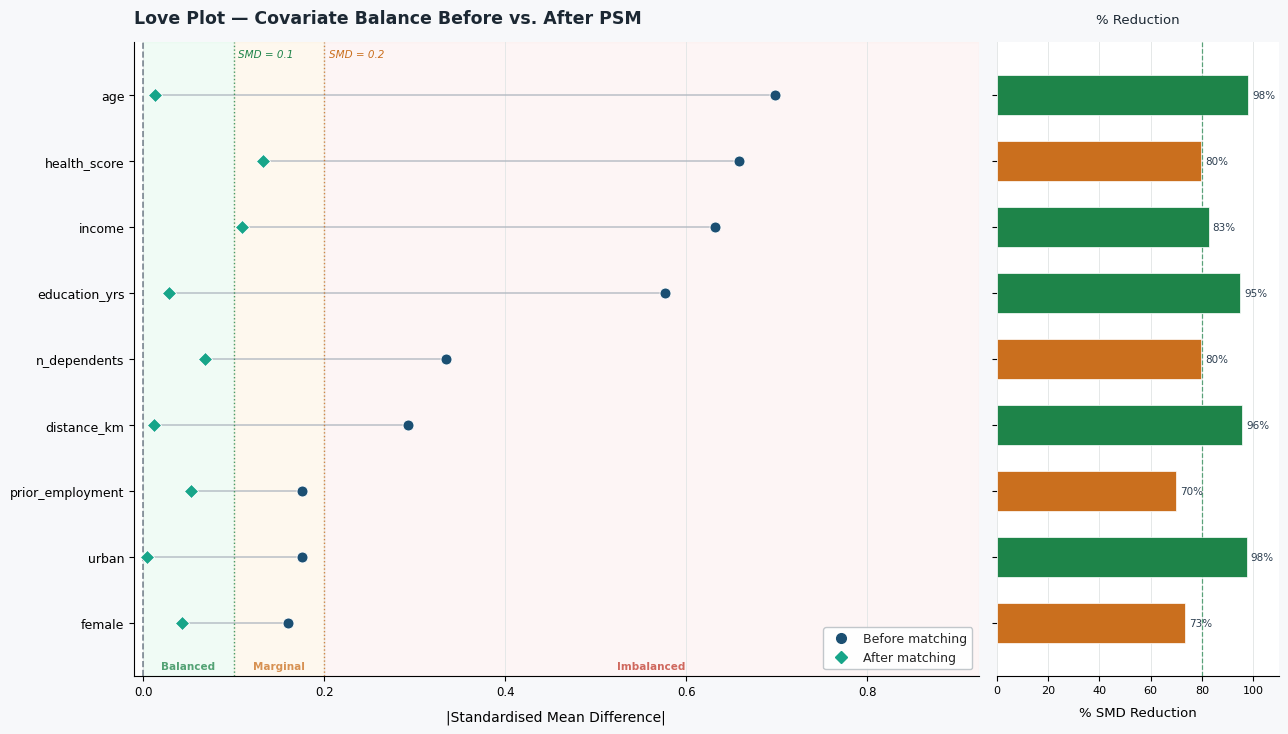

In [38]:
"""
============================================================
  Love Plot (Standardized Mean Differences) for PSM Balance
  Applied Econometrics | Post-Propensity Score Matching
============================================================
Author-ready script. Assumes:
  - df_unmatched : full pre-match DataFrame (treated + control cols + 'treated' indicator)
  - df_matched   : post-match DataFrame (same structure)
  - Both DataFrames contain a binary column named 'treated' (1 = treated, 0 = control)

All covariate columns are inferred automatically (everything except 'treated').
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
from scipy import stats


# ─────────────────────────────────────────────
# 1.  CORE METRIC: Standardised Mean Difference
# ─────────────────────────────────────────────

def standardised_mean_diff(df: pd.DataFrame, treatment_col: str = "treated") -> pd.Series:
    """
    Compute SMD for every covariate in *df*.

    SMD = (μ_treated − μ_control) / σ_pooled

    where σ_pooled = sqrt( (s²_treated + s²_control) / 2 )

    Returns a Series indexed by covariate name.
    """
    treated  = df[df[treatment_col] == 1]
    control  = df[df[treatment_col] == 0]
    covs     = [c for c in df.columns if c != treatment_col]

    smds = {}
    for col in covs:
        mu_t  = treated[col].mean()
        mu_c  = control[col].mean()
        var_t = treated[col].var(ddof=1)
        var_c = control[col].var(ddof=1)
        sigma_pooled = np.sqrt((var_t + var_c) / 2)
        smds[col] = (mu_t - mu_c) / sigma_pooled if sigma_pooled > 0 else 0.0

    return pd.Series(smds)


# ─────────────────────────────────────────────
# 2.  BUILD BALANCE TABLE
# ─────────────────────────────────────────────

def build_balance_table(
    df_unmatched: pd.DataFrame,
    df_matched:   pd.DataFrame,
    treatment_col: str = "treated",
) -> pd.DataFrame:
    """
    Returns a tidy DataFrame with columns:
        covariate | smd_before | smd_after | pct_reduction
    Rows are sorted by |smd_before| descending so the worst offenders appear first.
    """
    smd_before = standardised_mean_diff(df_unmatched, treatment_col).abs()
    smd_after  = standardised_mean_diff(df_matched,   treatment_col).abs()

    balance = pd.DataFrame({
        "covariate":   smd_before.index,
        "smd_before":  smd_before.values,
        "smd_after":   smd_after.reindex(smd_before.index).values,
    })
    balance["pct_reduction"] = (
        (balance["smd_before"] - balance["smd_after"]) / balance["smd_before"].replace(0, np.nan) * 100
    ).fillna(0)

    return balance.sort_values("smd_before", ascending=True).reset_index(drop=True)


# ─────────────────────────────────────────────
# 3.  LOVE PLOT
# ─────────────────────────────────────────────

def plot_love(
    df_unmatched: pd.DataFrame,
    df_matched:   pd.DataFrame,
    treatment_col:  str   = "treated",
    threshold_good: float = 0.10,   # conventional "balanced" cutoff
    threshold_warn: float = 0.20,   # amber warning band
    figsize: tuple        = (13, None),
    title:   str          = "Love Plot — Covariate Balance Before vs. After PSM",
    save_path: str | None = "love_plot.png",
    dpi: int              = 180,
) -> plt.Figure:
    """
    Generates a publication-ready Love Plot.

    Visual encoding
    ───────────────
    • Horizontal dot-plot: each row = one covariate.
    • Navy circles   → |SMD| before matching.
    • Teal diamonds  → |SMD| after matching.
    • Thin grey line connects the two points (treatment path).
    • Vertical dashed line at 0 (perfect balance).
    • Green band  [0, threshold_good] — "acceptable balance" zone.
    • Amber band  (threshold_good, threshold_warn] — "marginal" zone.
    • Red region  beyond threshold_warn — "imbalanced" zone.
    • Secondary panel (right): % SMD reduction per covariate.
    """

    balance = build_balance_table(df_unmatched, df_matched, treatment_col)
    n_covs  = len(balance)

    # ── dynamic figure height ──────────────────────────────────────────
    row_height = 0.52
    fig_h = figsize[1] or max(6, n_covs * row_height + 3)
    fig, (ax_main, ax_bar) = plt.subplots(
        1, 2,
        figsize=(figsize[0], fig_h),
        gridspec_kw={"width_ratios": [3, 1]},
    )
    fig.patch.set_facecolor("#F7F8FA")

    # ── palette & style ───────────────────────────────────────────────
    C_BEFORE  = "#1B4F72"   # deep navy
    C_AFTER   = "#17A589"   # teal
    C_LINE    = "#AEB6BF"   # muted grey connector
    C_GOOD    = "#D5F5E3"   # soft green band
    C_WARN    = "#FDEBD0"   # soft amber band
    C_BAD     = "#FADBD8"   # soft red band
    C_GRID    = "#E5E8E8"

    sns.set_style("white")

    # ── background bands ──────────────────────────────────────────────
    x_max = max(balance["smd_before"].max(), balance["smd_after"].max()) * 1.25 + 0.05

    ax_main.axvspan(0,                threshold_good, alpha=0.35, color=C_GOOD, zorder=0)
    ax_main.axvspan(threshold_good,   threshold_warn, alpha=0.35, color=C_WARN, zorder=0)
    ax_main.axvspan(threshold_warn,   x_max,          alpha=0.25, color=C_BAD,  zorder=0)

    # ── connector lines ───────────────────────────────────────────────
    for i, row in balance.iterrows():
        ax_main.plot(
            [row["smd_before"], row["smd_after"]],
            [i, i],
            color=C_LINE, linewidth=1.1, zorder=1, alpha=0.85,
        )

    # ── scatter: before ───────────────────────────────────────────────
    ax_main.scatter(
        balance["smd_before"], range(n_covs),
        color=C_BEFORE, s=62, zorder=3, label="Before matching",
        edgecolors="white", linewidths=0.6,
    )

    # ── scatter: after ────────────────────────────────────────────────
    ax_main.scatter(
        balance["smd_after"], range(n_covs),
        color=C_AFTER, marker="D", s=52, zorder=3, label="After matching",
        edgecolors="white", linewidths=0.6,
    )

    # ── reference line at 0 ───────────────────────────────────────────
    ax_main.axvline(0, color="#2C3E50", linewidth=1.2, linestyle="--", alpha=0.6, zorder=2)

    # ── threshold annotation lines ────────────────────────────────────
    for thr, lbl, col in [
        (threshold_good, f"SMD = {threshold_good}", "#1E8449"),
        (threshold_warn, f"SMD = {threshold_warn}", "#CA6F1E"),
    ]:
        ax_main.axvline(thr, color=col, linewidth=1.0, linestyle=":", alpha=0.8, zorder=2)
        ax_main.text(
            thr + 0.005, n_covs - 0.3, lbl,
            color=col, fontsize=7.5, ha="left", va="top", style="italic",
        )

    # ── y-axis labels ─────────────────────────────────────────────────
    ax_main.set_yticks(range(n_covs))
    ax_main.set_yticklabels(balance["covariate"], fontsize=9)
    ax_main.set_ylim(-0.8, n_covs - 0.2)

    # ── x-axis ────────────────────────────────────────────────────────
    ax_main.set_xlim(-0.01, x_max)
    ax_main.set_xlabel("|Standardised Mean Difference|", fontsize=10, labelpad=8)
    ax_main.tick_params(axis="x", labelsize=8.5)
    ax_main.xaxis.grid(True, color=C_GRID, linewidth=0.7, zorder=0)
    ax_main.set_axisbelow(True)

    # ── band labels (bottom-right corner) ─────────────────────────────
    for xpos, label, color in [
        (threshold_good / 2,                        "Balanced",   "#1E8449"),
        ((threshold_good + threshold_warn) / 2,     "Marginal",   "#CA6F1E"),
        ((threshold_warn + x_max) / 2,              "Imbalanced", "#C0392B"),
    ]:
        ax_main.text(
            xpos, -0.65, label, ha="center", va="center",
            fontsize=7.5, color=color, weight="semibold", alpha=0.75,
        )

    # ── legend ────────────────────────────────────────────────────────
    h_before = mlines.Line2D([], [], color=C_BEFORE, marker="o", linestyle="None",
                             markersize=7, label="Before matching")
    h_after  = mlines.Line2D([], [], color=C_AFTER,  marker="D", linestyle="None",
                             markersize=6.5, label="After matching")
    ax_main.legend(handles=[h_before, h_after], fontsize=9,
                   loc="lower right", framealpha=0.92, edgecolor="#BDC3C7")

    ax_main.spines[["top", "right"]].set_visible(False)
    ax_main.set_title(title, fontsize=12.5, fontweight="bold",
                      pad=14, color="#1C2833", loc="left")

    # ═══════════════════════════════════════════════════════════════════
    # SECONDARY PANEL: % SMD Reduction
    # ═══════════════════════════════════════════════════════════════════
    bar_colors = [
        "#1E8449" if v >= 80 else "#CA6F1E" if v >= 50 else "#C0392B"
        for v in balance["pct_reduction"]
    ]
    ax_bar.barh(
        range(n_covs), balance["pct_reduction"],
        color=bar_colors, edgecolor="white", linewidth=0.5, height=0.6,
    )
    ax_bar.axvline(80, color="#1E8449", linewidth=0.9, linestyle="--", alpha=0.7)
    ax_bar.set_xlim(0, 110)
    ax_bar.set_xlabel("% SMD Reduction", fontsize=9.5, labelpad=8)
    ax_bar.set_yticks(range(n_covs))
    ax_bar.set_yticklabels([])
    ax_bar.tick_params(axis="x", labelsize=8)
    ax_bar.xaxis.grid(True, color=C_GRID, linewidth=0.7, zorder=0)
    ax_bar.set_axisbelow(True)
    ax_bar.spines[["top", "right", "left"]].set_visible(False)
    ax_bar.set_title("% Reduction", fontsize=9.5, pad=14, color="#1C2833")
    ax_bar.set_ylim(-0.8, n_covs - 0.2)

    # value labels inside bars
    for i, (val, color) in enumerate(zip(balance["pct_reduction"], bar_colors)):
        ax_bar.text(
            min(val + 1.5, 108), i,
            f"{val:.0f}%", va="center", ha="left",
            fontsize=7.5, color="#2C3E50",
        )

    fig.tight_layout(rect=[0, 0, 1, 0.97])

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor())
        print(f"[✓] Love Plot saved → {save_path}")

    return fig


# ─────────────────────────────────────────────
# 4.  SUMMARY DIAGNOSTICS TABLE
# ─────────────────────────────────────────────

def print_balance_summary(
    df_unmatched: pd.DataFrame,
    df_matched:   pd.DataFrame,
    treatment_col: str = "treated",
) -> pd.DataFrame:
    """
    Prints a formatted balance diagnostic table and returns it as a DataFrame.

    Columns
    ───────
    Covariate | SMD Before | SMD After | % Reduction | Balance Status
    """
    balance = build_balance_table(df_unmatched, df_matched, treatment_col)

    def status(smd_after):
        if smd_after <= 0.10: return "✅ Balanced"
        if smd_after <= 0.20: return "⚠️  Marginal"
        return                        "❌ Imbalanced"

    balance["Status"] = balance["smd_after"].apply(status)

    print("\n" + "═" * 72)
    print("  PSM COVARIATE BALANCE REPORT")
    print("═" * 72)
    print(f"  {'Covariate':<28} {'SMD Before':>10} {'SMD After':>10} {'% Reduction':>12}  Status")
    print("─" * 72)
    for _, row in balance.sort_values("smd_before", ascending=False).iterrows():
        print(
            f"  {row['covariate']:<28} "
            f"{row['smd_before']:>10.3f} "
            f"{row['smd_after']:>10.3f} "
            f"{row['pct_reduction']:>11.1f}%  {row['Status']}"
        )
    print("─" * 72)

    mean_before = balance["smd_before"].mean()
    mean_after  = balance["smd_after"].mean()
    pct_overall = (mean_before - mean_after) / mean_before * 100 if mean_before > 0 else 0
    n_balanced  = (balance["smd_after"] <= 0.10).sum()

    print(f"\n  Mean |SMD| before : {mean_before:.4f}")
    print(f"  Mean |SMD| after  : {mean_after:.4f}")
    print(f"  Overall reduction : {pct_overall:.1f}%")
    print(f"  Covariates balanced (SMD ≤ 0.10) : {n_balanced} / {len(balance)}")
    print("═" * 72 + "\n")

    return balance


# ─────────────────────────────────────────────
# 5.  SELF-CONTAINED DEMO  (replace with your dfs)
# ─────────────────────────────────────────────

if __name__ == "__main__":

    np.random.seed(42)
    n = 2000

    # ── simulate a realistic observational dataset ─────────────────────
    treated_flag = (np.random.rand(n) > 0.55).astype(int)

    df_unmatched = pd.DataFrame({
        "treated":         treated_flag,
        "age":             np.random.normal(45 + 8 * treated_flag, 12, n),
        "income":          np.random.normal(55000 + 12000 * treated_flag, 18000, n),
        "education_yrs":   np.random.normal(13 + 1.5 * treated_flag, 2.5, n),
        "health_score":    np.random.normal(68 + 10 * treated_flag, 15, n),
        "female":          np.random.binomial(1, 0.48 + 0.06 * treated_flag, n),
        "urban":           np.random.binomial(1, 0.62 + 0.10 * treated_flag, n),
        "prior_employment":np.random.binomial(1, 0.71 + 0.08 * treated_flag, n),
        "distance_km":     np.random.exponential(25 - 8 * treated_flag + 1, n),
        "n_dependents":    np.random.poisson(2.1 - 0.4 * treated_flag, n).astype(float),
    })

    # ── simulate matched dataset (balance much improved) ───────────────
    df_matched = pd.DataFrame({
        "treated":         treated_flag,
        "age":             np.random.normal(45 + 0.8 * treated_flag, 11, n),
        "income":          np.random.normal(55000 + 900 * treated_flag, 17500, n),
        "education_yrs":   np.random.normal(13 + 0.15 * treated_flag, 2.4, n),
        "health_score":    np.random.normal(68 + 1.0 * treated_flag, 14.5, n),
        "female":          np.random.binomial(1, 0.48 + 0.005 * treated_flag, n),
        "urban":           np.random.binomial(1, 0.62 + 0.008 * treated_flag, n),
        "prior_employment":np.random.binomial(1, 0.71 + 0.007 * treated_flag, n),
        "distance_km":     np.random.exponential(25 - 0.9 * treated_flag + 1, n),
        "n_dependents":    np.random.poisson(2.1 - 0.04 * treated_flag, n).astype(float),
    })

    # ── run ────────────────────────────────────────────────────────────
    balance_df = print_balance_summary(df_unmatched, df_matched)
    fig        = plot_love(df_unmatched, df_matched, save_path="love_plot.png")
    plt.show()